In [1]:
import pandas as pd
import pysam
import os
import json

In [2]:
comp = str.maketrans("ACGTNacgtn", "TGCANtgcan")
#rc = str(CordSeq3+CordSeq4).translate(comp)[::-1]

# assemblies

In [3]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [4]:
df = pd.read_csv("/LeeLab/HPRC/chromosomeY/QC/LocationFiles/AZFc_QC_File.csv")

In [5]:
colorDict={
    'blue':'#1307b3',
    'blue-plus':'#1307b3',
    'blue-IR1':'#1307b3',
    'teal':'#02a4a8',
    'green':'#00a115',
    'green-plus':'#00a115',
    'green-IR1':'#00a115',
    'red':'#940003',
    'gray':'#808080',
    'yellow':'#ffff00',
    'spacer':'white'}
colorList=[]
for color in df['colorblock']:
    if 'spacer' in color:
        colorList.append('spacer')
    elif 'plus' in color:
        color1 = color.split("-")[0][:-1]
        colorList.append(color1+'-plus')
    elif 'IR1' in color:
        color1 = color.split("-")[0][:-1]
        colorList.append(color1+'-IR1')
    else:
        colorList.append(color[:-1])
df['MainColor']=colorList
df['ColorHEX']=[colorDict[x] for x in colorList]

In [6]:
dazDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/HGSVC3_HPRC_CEPH_DAZ_RRM_CopyNumbers_09152025.csv").set_index("contig")
dazDF

,Unnamed: 0,sample,exonList
contig,,,
HG02984_chrY,0,HG02984,"[1, 2, 3, 1]"
HG01890_chrY,1,HG01890,"[1, 2, 1, 3]"
HG02647_chrY,2,HG02647,"[3, 1, 1, 2]"
HG02666_chrY,3,HG02666,"[3, 1, 1, 2]"
HG02668_chrY,4,HG02668,"[3, 1, 1, 2]"
...,...,...,...
HG00126_chrY,178,HG00126,"[3, 1, 1, 2]"
NA20752_chrY,179,NA20752,"[3, 1, 1, 2]"
HG01261_chrY,180,HG01261,"[3, 1]"


In [7]:
import ast
df['RRMs']=0
for sample in set(df['sample']):
    test = df[df['sample']==sample].copy()
    tempList = ast.literal_eval(str(dazDF.at[sample+'_chrY','exonList']))
    for row, gene in zip(test[test['colorblock'].str.contains("red")].index, tempList):
        df.at[row,'RRMs']=gene

## pairings

In [8]:
from collections import defaultdict
from typing import Dict, List, Any, Optional

def kmer_counts_and_positions(
    seq: str,
    k: int,
    *,
    one_based: bool = False,
    ignore_case: bool = True,
    skip_ambiguous: bool = True,
    alphabet: str = "ACGT",
) -> Dict[str, Dict[str, Any]]:
    """
    Build a dictionary of k-mers -> {"count": int, "positions": [int, ...]}.

    Positions are start indices of each k-mer occurrence.

    Parameters
    ----------
    seq : str
        DNA sequence.
    k : int
        k-mer length.
    one_based : bool
        If True, positions are 1-based; otherwise 0-based.
    ignore_case : bool
        If True, uppercase the sequence first.
    skip_ambiguous : bool
        If True, skip any k-mer containing characters not in `alphabet`.
    alphabet : str
        Allowed characters (default "ACGT").

    Returns
    -------
    dict
        Example:
        {
          "ACG": {"count": 2, "positions": [0, 5]},
          "CGT": {"count": 1, "positions": [1]},
        }
    """
    if k <= 0:
        raise ValueError("k must be >= 1")
    if not isinstance(seq, str):
        raise TypeError("seq must be a string")

    s = seq.upper() if ignore_case else seq
    n = len(s)
    if k > n:
        return {}

    allowed = set(alphabet.upper() if ignore_case else alphabet)

    out: Dict[str, Dict[str, Any]] = defaultdict(lambda: {"count": 0, "positions": []})
    offset = 1 if one_based else 0

    for i in range(0, n - k + 1):
        kmer = s[i : i + k]
        if skip_ambiguous and any(ch not in allowed for ch in kmer):
            continue
        rec = out[kmer]
        rec["count"] += 1
        rec["positions"].append(i + offset)

    return dict(out)


## Pull sequences

In [9]:
import hashlib
import matplotlib as mpl
mpl.use("pdf")
mpl.rcParams["figure.facecolor"]  = "white"
mpl.rcParams["axes.facecolor"]    = "white"
mpl.rcParams["savefig.facecolor"] = "white"

import matplotlib.pyplot as plt
from pygenomeviz import GenomeViz


def stable_hex_for_kmer(kmer: str) -> str:
    h = hashlib.md5(kmer.encode("utf-8")).hexdigest()
    r = (int(h[0:2], 16) // 2) + 64
    g = (int(h[2:4], 16) // 2) + 64
    b = (int(h[4:6], 16) // 2) + 64
    return f"#{r:02x}{g:02x}{b:02x}"


def build_kmer2color(shared_unique_dict):
    return {kmer: stable_hex_for_kmer(kmer) for kmer in shared_unique_dict.keys()}


def plot_two_samples_blocks_and_kmers_unique_colors_pgv161(
    df,
    samples,
    shared_unique_dict,
    *,
    start_col="start",
    end_col="end",
    orient_col="orientation",   
    colorhex_col="ColorHEX",
    rrms_col="RRMs",            
    baseline_lw=0.9,
    fig_width=14,
    fig_track_height=0.35,
    feature_track_ratio=0.85,
    labelsize=12,
    show_scale_bar=True,
    scale_bp=1_000_000,
    scale_label="1 Mb",
    scale_labelsize=15,
    scale_ymargin=1.0,
    k=24,
    kmer_plotstyle="box",
    kmer_ec="black",
    kmer_lw=0.0,
    kmer_alpha=1.0,
    sample2kmer_window_start=None,
    outpath_pdf=None,
    outpath_jpg=None,
    jpg_dpi=300,
):
    if len(samples) != 2:
        raise ValueError("Provide exactly two samples, e.g. ['HG005','HG02572'].")

    df_sub = df[df["sample"].isin(samples)].copy()
    if df_sub.empty:
        raise ValueError("No rows found for provided samples in df.")

    df_sub[start_col] = df_sub[start_col].astype(int)
    df_sub[end_col] = df_sub[end_col].astype(int)

    global_min = int(df_sub[start_col].min())
    global_max = int(df_sub[end_col].max())

    def norm_pos(abs_coord: int) -> int:
        return int(abs_coord) - global_min + 1

    global_size = norm_pos(global_max)

    if sample2kmer_window_start is None:
        sample2kmer_window_start = {
            s: int(df_sub.loc[df_sub["sample"] == s, start_col].min())
            for s in samples
        }
    else:
        for s in samples:
            if s not in sample2kmer_window_start:
                raise ValueError(f"sample2kmer_window_start missing key for sample '{s}'")

    kmer2color = build_kmer2color(shared_unique_dict)

    gv = GenomeViz(
        track_align_type="left",
        fig_width=fig_width,
        fig_track_height=fig_track_height,
        feature_track_ratio=feature_track_ratio,
    )

    if show_scale_bar:
        gv.set_scale_bar(
            scale_size_label=(scale_bp, scale_label),
            labelsize=scale_labelsize,
            ymargin=scale_ymargin,
        )

    tracks = {}
    sample2seg_bounds = {}
    for s in samples:
        sdf = df_sub[df_sub["sample"] == s].copy()
        s_min_abs = int(sdf[start_col].min())
        s_max_abs = int(sdf[end_col].max())

        s_min_norm = norm_pos(s_min_abs)
        s_max_norm = norm_pos(s_max_abs)

        segments = {"region": (s_min_norm, s_max_norm)}  # trims baseline
        tracks[s] = gv.add_feature_track(
            s,
            segments,
            labelsize=labelsize,
            label_kws=dict(color="black"),
            line_kws=dict(color="black", lw=baseline_lw, alpha=1.0),
        )
        sample2seg_bounds[s] = (s_min_norm, s_max_norm)


    def rrms_to_hatch(val) -> str | None:
        try:
            if val is None:
                return None
            v = int(val)
        except Exception:
            return None
        if v == 2:
            return "-----"
        if v == 3:
            return "/////"
        return None  

    for s in samples:
        sdf = df_sub[df_sub["sample"] == s].sort_values([start_col, end_col])
        track = tracks[s]
        seg_start, seg_end = sample2seg_bounds[s]

        for _, row in sdf.iterrows():
            a = int(row[start_col]); b = int(row[end_col])
            if b < a:
                a, b = b, a

            start = norm_pos(a)
            end = norm_pos(b)

            start = max(seg_start, start)
            end = min(seg_end, end)
            if end <= start:
                continue

            orient = str(row[orient_col]).strip().lower()
            strand = 1 if orient == "sense" else -1

            fc = str(row[colorhex_col])
            hatch = rrms_to_hatch(row.get(rrms_col, None))

            feat_kws = dict(
                plotstyle="bigarrow",
                ec="black",
                fc=fc,
                lw=0.5,
                label="",
                text_kws=None,
            )
            if hatch is not None:
                feat_kws["hatch"] = hatch

            track.add_feature(start, end, strand, **feat_kws)

    for kmer, per_sample in shared_unique_dict.items():
        fc = kmer2color[kmer]

        for s in samples:
            info = per_sample.get(s)
            if not info:
                continue

            win_start_abs = int(sample2kmer_window_start[s])
            track = tracks[s]
            seg_start, seg_end = sample2seg_bounds[s]

            for pos0 in info.get("positions", []):
                abs_start_1based = win_start_abs + int(pos0)
                abs_end_1based = abs_start_1based + int(k) - 1

                start = norm_pos(abs_start_1based)
                end = norm_pos(abs_end_1based)

                start = max(seg_start, start)
                end = min(seg_end, end)
                if end <= start:
                    continue

                track.add_feature(
                    start, end, 1,
                    plotstyle=kmer_plotstyle,
                    ec=kmer_ec,
                    fc=fc,
                    lw=kmer_lw,
                    alpha=kmer_alpha,
                    label="",
                    text_kws=None,
                )

    fig = gv.plotfig()
    for ax in fig.axes:
        if ax.has_data():
            ax.set_xlim(0, global_size)

    if outpath_pdf:
        fig.savefig(outpath_pdf, bbox_inches="tight")
    if outpath_jpg:
        fig.savefig(outpath_jpg, dpi=jpg_dpi, bbox_inches="tight")

    return fig

HG01099 unique_kmers(count==1): 2474
NA20870 unique_kmers(count==1): 1402
shared unique k-mers: 773


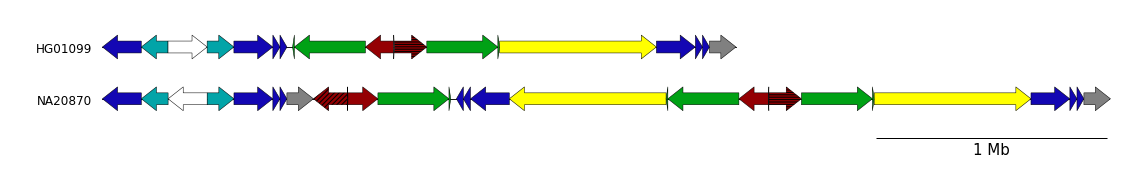

In [10]:
group = ['HG01099', 'NA20870']
samples=group
kmer = 8

sample2unique = {}
sample2kmer_window_start = {}

for sample in group:
    tempDF = df[df["sample"] == sample].copy()
    contig = f"{sample}_chrY"
    start = int(tempDF["start"].astype(int).min())
    end   = int(tempDF["end"].astype(int).max())

    sample2kmer_window_start[sample] = start 

    coordinate = f"{contig}:{start}-{end}"
    sequence = "".join(pysam.faidx(assemblyDict[sample], coordinate).split()[1:])

    tempDict = kmer_counts_and_positions(sequence, kmer)

    uniqueDict = {km: info for km, info in tempDict.items() if info["count"] ==1}
    sample2unique[sample] = uniqueDict

    print(sample, "unique_kmers(count==1):", len(uniqueDict))

s1, s2 = group[0], group[1]
shared_unique_kmers = set(sample2unique[s1]).intersection(sample2unique[s2])

shared_unique_dict = {
    km: {s1: sample2unique[s1][km], s2: sample2unique[s2][km]}
    for km in shared_unique_kmers
}

print("shared unique k-mers:", len(shared_unique_dict))

fig = plot_two_samples_blocks_and_kmers_unique_colors_pgv161(
    df=df,
    samples=samples,
    shared_unique_dict=shared_unique_dict,
    k=kmer,
    outpath_pdf="/LeeLab/HPRC/chromosomeY/Figures/Deletion_Breakpoints/Deletion_"+str(samples[0])+"-"+str(samples[1])+"_"+str(kmer)+"mer.pdf",
)
plt.show()

In [ ]:
HG00358 unique_kmers(count==1): 2689
HG02074 unique_kmers(count==1): 1407
shared unique k-mers: 641

In [ ]:
HG00290 unique_kmers(count==1): 2688
HG02074 unique_kmers(count==1): 1407
shared unique k-mers: 641

In [ ]:
NA18747 unique_kmers(count==1): 2688
HG02074 unique_kmers(count==1): 1407
shared unique k-mers: 749

In [ ]:
HG00329 unique_kmers(count==1): 2692
HG02074 unique_kmers(count==1): 1407
shared unique k-mers: 641

In [ ]:
HG005 unique_kmers(count==1): 2442
HG02572 unique_kmers(count==1): 1390
shared unique k-mers: 876

In [ ]:
NA18952 unique_kmers(count==1): 2449
HG02572 unique_kmers(count==1): 1390
shared unique k-mers: 873

In [ ]:
NA18983 unique_kmers(count==1): 2363
HG02572 unique_kmers(count==1): 1390
shared unique k-mers: 779

In [ ]:
HG01099 unique_kmers(count==1): 2474
HG03579 unique_kmers(count==1): 1427
shared unique k-mers: 946

In [ ]:
HG04228 unique_kmers(count==1): 2465
HG04115 unique_kmers(count==1): 1435
shared unique k-mers: 961

In [ ]:
HG02135 unique_kmers(count==1): 2438
HG02071 unique_kmers(count==1): 1421
shared unique k-mers: 934

In [ ]:
HG02129 unique_kmers(count==1): 2462
HG02071 unique_kmers(count==1): 1421
shared unique k-mers: 798